# SSVEP EDA — Lee2019 

This notebook is the **simplified, primary analysis**.

Its goal is deliberately narrow:

1. load and inspect the Lee2019 SSVEP data,
2. select posterior EEG channels,
3. verify the SSVEP structure using time-domain / PSD / SNR analysis,
4. establish a standard CCA baseline,

The four classes correspond to the four Lee2019 stimulation frequencies:

```text
5.45 Hz, 6.67 Hz, 8.57 Hz, 12.00 Hz
```



# 2. Dataset description

## 2.1 Dataset selection

The Lee2019_SSVEP dataset was selected because it is a public SSVEP dataset available through MOABB and uses four stimulation frequencies mapped to four directional commands. This makes it particularly suitable for an exploratory analysis of a future control system based on up/down/left/right visual commands.

## 2.2 Lee2019_SSVEP details

According to the MOABB documentation, Lee2019_SSVEP contains 54 subjects, 62 EEG channels, 2 sessions, a native sampling frequency of 1000 Hz and 4-second SSVEP trials. The four target frequencies are:

```text
5.45 Hz, 6.67 Hz, 8.57 Hz, 12.00 Hz
```

The corresponding directional mapping in the MOABB dataset implementation is:

```text
5.45 Hz -> down
6.67 Hz -> right
8.57 Hz -> left
12.00 Hz -> up
```

The original recordings are sampled at 1000 Hz. In this notebook, the MOABB paradigm resamples the data to `FS = 250 Hz` to reduce memory and computation while preserving the frequency range used by the analysis.

## 2.3 Dataset limitations

This analysis is offline and dataset-based. Therefore, the obtained classification accuracy should not be interpreted as direct proof that a real-time drone control system would work reliably. A practical online system would require:

- hardware validation with the actual LEDs or visual display,
- subject-specific calibration,
- online testing,
- artifact handling,
- confidence thresholds and safety mechanisms.

The complete OpenBMI dataset is large. For practical development, the loading section uses a configurable subset of subjects by default; the full subject list can be enabled with one line.


# 3. Environment and configuration

## 3.1 Libraries

In [1]:
import warnings
warnings.simplefilter("default")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from scipy.signal import welch, cheby1, butter, sosfiltfilt
from scipy.linalg import eigh
from sklearn.cross_decomposition import CCA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from moabb.datasets import Lee2019_SSVEP
from moabb.paradigms import SSVEP

/home/kacper/github/TALON/.venv/lib/python3.12/site-packages/moabb/analysis/plotting.py:110: PendingDeprecationWarning: The set_under function will be deprecated in a future version. Use cmap.with_extremes(under=...) or Colormap(under=...) instead.
  _MOABB_SIGNIFICANCE_CMAP.set_under(color=[1, 1, 1])
/home/kacper/github/TALON/.venv/lib/python3.12/site-packages/moabb/analysis/plotting.py:111: PendingDeprecationWarning: The set_over function will be deprecated in a future version. Use cmap.with_extremes(over=...) or Colormap(over=...) instead.
  _MOABB_SIGNIFICANCE_CMAP.set_over(color=MOABB_CORAL)
/home/kacper/github/TALON/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/kacper/github/TALON/.venv/lib/python3.12/site-packages/moabb/pipelines/classification.py:8: DeprecationWarning: pyriemann.ut

## 3.2 Global constants

The channel names below correspond to the 62 EEG channels returned by the Lee2019_SSVEP / OpenBMI recordings.


In [2]:
FS = 250

TARGET_FREQS_ALL = [5.45, 6.67, 8.57, 12.00]

LEE2019_CHANNELS = [
    "Fp1", "Fp2", "F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2",
    "FC6", "T7", "C3", "Cz", "C4", "T8", "TP9", "CP5", "CP1", "CP2",
    "CP6", "TP10", "P7", "P3", "Pz", "P4", "P8", "PO9", "O1", "Oz",
    "O2", "PO10", "FC3", "FC4", "C5", "C1", "C2", "C6", "CP3", "CPz",
    "CP4", "P1", "P2", "POz", "FT9", "FTT9h", "TTP7h", "TP7", "TPP9h",
    "FT10", "FTT10h", "TPP8h", "TP8", "TPP10h", "F9", "F10", "AF7",
    "AF3", "AF4", "AF8", "PO3", "PO4",
]

POSTERIOR_CHANNELS = ["PO9", "PO3", "POz", "PO4", "PO10", "O1", "Oz", "O2"]

POSTERIOR_CHANNEL_INDICES = [
    LEE2019_CHANNELS.index(channel)
    for channel in POSTERIOR_CHANNELS
]

RANDOM_STATE = 42


## 3.3 Analysis configuration

Use this cell to quickly switch between the full 4-class setup and reduced frequency subsets.


In [3]:
# Default: full 4-class Lee2019_SSVEP problem.
SELECTED_TARGET_FREQS = TARGET_FREQS_ALL.copy()

# Exploratory 3-class subset excluding 5.45 Hz.
# This subset should be treated as a design experiment, not as an unbiased final benchmark.
# SELECTED_TARGET_FREQS = [6.67, 8.57, 12.00]

# Exploratory 2-class subset.
# Its performance should not be compared directly with the full 4-class problem.
# SELECTED_TARGET_FREQS = [8.57, 12.00]


# 4. Helper functions

## 4.1 Filtering functions

In [4]:
def cheby_bandpass_filter_signal(
    signal: np.ndarray,
    lowcut: float,
    highcut: float,
    fs: int,
    order: int = 4,
    ripple_db: float = 0.5,
) -> np.ndarray:
    """Band-pass filters one EEG channel using a zero-phase Chebyshev type I filter."""
    nyq = 0.5 * fs

    if lowcut <= 0:
        raise ValueError("lowcut must be greater than 0.")
    if highcut >= nyq:
        raise ValueError(f"highcut must be lower than Nyquist frequency: {nyq} Hz.")

    sos = cheby1(
        N=order,
        rp=ripple_db,
        Wn=[lowcut / nyq, highcut / nyq],
        btype="bandpass",
        output="sos",
    )
    return sosfiltfilt(sos, signal)


def butter_bandpass_filter_signal(
    signal: np.ndarray,
    lowcut: float,
    highcut: float,
    fs: int,
    order: int = 4,
) -> np.ndarray:
    """Band-pass filters one EEG channel using a zero-phase Butterworth filter."""
    nyq = 0.5 * fs

    if lowcut <= 0:
        raise ValueError("lowcut must be greater than 0.")
    if highcut >= nyq:
        raise ValueError(f"highcut must be lower than Nyquist frequency: {nyq} Hz.")

    sos = butter(
        N=order,
        Wn=[lowcut / nyq, highcut / nyq],
        btype="bandpass",
        output="sos",
    )
    return sosfiltfilt(sos, signal)


def filter_trial(
    trial: np.ndarray,
    lowcut: float,
    highcut: float,
    fs: int,
    order: int = 4,
    filter_type: str = "butter",
) -> np.ndarray:
    """Applies a band-pass filter independently to every EEG channel in one trial.

    Args:
        trial: EEG trial with shape (n_channels, n_samples).
        filter_type: "butter" or "cheby".

    Returns:
        Filtered trial with the same shape.
    """
    filtered_trial = np.zeros_like(trial, dtype=float)

    for ch_idx in range(trial.shape[0]):
        if filter_type == "butter":
            filtered_trial[ch_idx] = butter_bandpass_filter_signal(
                trial[ch_idx], lowcut=lowcut, highcut=highcut, fs=fs, order=order
            )
        elif filter_type == "cheby":
            filtered_trial[ch_idx] = cheby_bandpass_filter_signal(
                trial[ch_idx], lowcut=lowcut, highcut=highcut, fs=fs, order=order
            )
        else:
            raise ValueError("filter_type must be either 'butter' or 'cheby'.")

    return filtered_trial


def filter_eeg_trials(
    trials: np.ndarray,
    lowcut: float,
    highcut: float,
    fs: int,
    order: int = 4,
    filter_type: str = "cheby",
) -> np.ndarray:
    """Applies a band-pass filter to all trials and channels."""
    filtered = np.zeros_like(trials, dtype=float)

    for trial_idx, trial in enumerate(trials):
        filtered[trial_idx] = filter_trial(
            trial=trial,
            lowcut=lowcut,
            highcut=highcut,
            fs=fs,
            order=order,
            filter_type=filter_type,
        )

    return filtered

## 4.2 PSD and SNR functions

In [5]:
def compute_trial_mean_psd(
    trial: np.ndarray,
    fs: int,
    nperseg: int | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """Computes PSD for each channel and returns the channel-averaged PSD."""
    if nperseg is None:
        nperseg = trial.shape[1]

    channel_psds = []
    freqs = None

    for ch_idx in range(trial.shape[0]):
        freqs, psd = welch(
            trial[ch_idx],
            fs=fs,
            nperseg=min(nperseg, trial.shape[1]),
        )
        channel_psds.append(psd)

    mean_psd = np.mean(channel_psds, axis=0)
    return freqs, mean_psd


def get_nearest_freq_idx(freqs: np.ndarray, target_freq: float) -> int:
    """Returns the index of the frequency bin closest to target_freq."""
    freqs = np.asarray(freqs)

    if freqs.size == 0:
        raise ValueError("Frequency array cannot be empty.")
    if target_freq < 0 or np.any(freqs < 0):
        raise ValueError("Frequencies must be non-negative.")

    return int(np.argmin(np.abs(freqs - target_freq)))


def compute_snr_at_freq(
    freqs: np.ndarray,
    psd: np.ndarray,
    target_freq: float,
    noise_width: int = 2,
    skip_width: int = 1,
) -> tuple[float, float]:
    """Computes local SNR around a target frequency.

    The function expects linear PSD values, not dB-transformed PSD.
    """
    freqs = np.asarray(freqs)
    psd = np.asarray(psd)

    if noise_width < 1 or skip_width < 0:
        raise ValueError("noise_width must be >= 1 and skip_width must be >= 0.")
    if len(freqs) != len(psd):
        raise ValueError("freqs and psd must have the same length.")
    if np.any(psd < 0):
        raise ValueError("PSD values must be non-negative. Pass linear PSD, not dB PSD.")

    idx = get_nearest_freq_idx(freqs, target_freq)
    signal_power = psd[idx]

    left_start = idx - skip_width - noise_width
    left_end = idx - skip_width
    right_start = idx + skip_width + 1
    right_end = idx + skip_width + noise_width + 1

    if left_start < 0 or right_end > len(psd):
        return np.nan, np.nan

    noise_bins = np.concatenate([
        psd[left_start:left_end],
        psd[right_start:right_end],
    ])
    noise_power = np.mean(noise_bins)

    if signal_power <= 0 or noise_power <= 0:
        return np.nan, np.nan

    snr = signal_power / noise_power
    snr_db = 10 * np.log10(snr)

    return float(snr), float(snr_db)

## 4.3 CCA reference generation

In [6]:
def generate_reference_signals(
    freq: float,
    n_samples: int,
    fs: int,
    n_harmonics: int = 3,
) -> np.ndarray:
    """Generates sine/cosine reference signals for a stimulation frequency.

    Shape:
        (2 * n_harmonics, n_samples)
    """
    t = np.arange(n_samples) / fs
    refs = []

    for h in range(1, n_harmonics + 1):
        refs.append(np.sin(2 * np.pi * h * freq * t))
        refs.append(np.cos(2 * np.pi * h * freq * t))

    return np.vstack(refs)

## 4.4 CCA utility function

In [7]:
def get_cca_correlation(data: np.ndarray, ref: np.ndarray) -> float:
    """Computes the first canonical correlation between EEG data and reference signals.

    Args:
        data: EEG data with shape (n_channels, n_samples).
        ref: Reference signals with shape (n_reference_signals, n_samples).
    """
    X = data.T
    Y = ref.T

    cca = CCA(n_components=1, max_iter=1000)
    X_c, Y_c = cca.fit_transform(X, Y)

    corr = np.corrcoef(X_c[:, 0], Y_c[:, 0])[0, 1]

    if np.isnan(corr):
        return 0.0

    return float(corr)

## 4.5 Evaluation functions

In [8]:
def add_metadata_to_result(
    result: dict,
    metadata: pd.DataFrame | None,
    trial_idx: int,
) -> dict:
    """Adds subject/session/run metadata to a result dict when available."""
    if metadata is None:
        return result

    for column in ["subject", "session", "run"]:
        if column in metadata.columns:
            result[column] = metadata.iloc[trial_idx][column]

    return result


def format_frequency_labels(values) -> pd.Series:
    """Converts frequency labels to categorical strings.

    sklearn classification metrics treat non-integer float labels such as
    5.45, 6.67 or 12.00 as continuous targets. Therefore, all frequency
    labels are rounded and formatted as categorical strings before using
    accuracy_score, balanced_accuracy_score, classification_report or
    confusion_matrix.
    """
    return (
        pd.Series(values)
        .astype(float)
        .round(2)
        .map(lambda x: f"{x:.2f}")
    )


def safe_accuracy(df: pd.DataFrame) -> float:
    """Computes accuracy for frequency labels stored as floats."""
    y_true = format_frequency_labels(df["true_label"])
    y_pred = format_frequency_labels(df["predicted_label"])
    return accuracy_score(y_true, y_pred)


def safe_balanced_accuracy(df: pd.DataFrame) -> float:
    """Computes balanced accuracy for frequency labels stored as floats."""
    y_true = format_frequency_labels(df["true_label"])
    y_pred = format_frequency_labels(df["predicted_label"])
    return balanced_accuracy_score(y_true, y_pred)


def print_metrics(df: pd.DataFrame, name: str) -> None:
    """Prints accuracy, balanced accuracy and classification report."""
    y_true = format_frequency_labels(df["true_label"])
    y_pred = format_frequency_labels(df["predicted_label"])

    print(f"{name} accuracy: {accuracy_score(y_true, y_pred):.2%}")
    print(f"{name} balanced accuracy: {balanced_accuracy_score(y_true, y_pred):.2%}")
    print()
    print(classification_report(y_true, y_pred, digits=3, zero_division=0))


def per_class_accuracy(df: pd.DataFrame) -> pd.Series:
    """Returns accuracy for each true class."""
    return (
        df
        .assign(true_label=df["true_label"].astype(float).round(2))
        .groupby("true_label")["correct"]
        .mean()
        .sort_index()
    )


def plot_confusion(
    df: pd.DataFrame,
    labels_order: list[float],
    title: str,
    normalize: str | None = "true",
) -> None:
    """Plots a confusion matrix for frequency-class labels."""
    y_true = format_frequency_labels(df["true_label"])
    y_pred = format_frequency_labels(df["predicted_label"])
    labels_order_str = [f"{float(label):.2f}" for label in labels_order]

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels_order_str,
        normalize=normalize,
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels_order_str,
    )
    disp.plot(values_format=".2f" if normalize is not None else "d")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def summarize_model_results(model_results: list[dict]) -> pd.DataFrame:
    """Builds a compact model comparison table."""
    rows = []

    for item in model_results:
        name = item["model"]
        df = item["df"]
        n_classes = item["n_classes"]
        comment = item.get("comment", "")

        acc = safe_accuracy(df)
        bal_acc = safe_balanced_accuracy(df)
        chance = 1 / n_classes

        rows.append({
            "model": name,
            "n_classes": n_classes,
            "chance_level": chance,
            "accuracy": acc,
            "balanced_accuracy": bal_acc,
            "gain_over_chance": acc - chance,
            "comment": comment,
        })

    return pd.DataFrame(rows).sort_values("accuracy", ascending=False)


def plot_accuracy_bar(summary_df: pd.DataFrame) -> None:
    """Plots model accuracy comparison."""
    ax = summary_df.sort_values("accuracy").plot(
        x="model",
        y="accuracy",
        kind="barh",
        legend=False,
        figsize=(8, 4),
    )
    ax.set_xlabel("Accuracy")
    ax.set_ylabel("Model")
    ax.set_title("Model accuracy comparison")
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.show()


def make_frequency_subset(
    X: np.ndarray,
    labels_float: np.ndarray,
    metadata: pd.DataFrame | None,
    selected_target_freqs: list[float],
    channel_indices: list[int],
) -> tuple[np.ndarray, np.ndarray, pd.DataFrame | None, np.ndarray]:
    """Selects trials belonging to selected frequencies and extracts selected channels."""
    mask = np.isin(labels_float.astype(float), selected_target_freqs)

    X_selected = X[mask]
    labels_selected = labels_float[mask].astype(float)
    X_selected_channels = X_selected[:, channel_indices, :]

    if metadata is not None:
        metadata_selected = metadata.loc[mask].reset_index(drop=True)
    else:
        metadata_selected = None

    return X_selected, labels_selected, metadata_selected, X_selected_channels

def select_frequency_subset(
    trials: np.ndarray,
    labels: np.ndarray,
    metadata: pd.DataFrame | None,
    selected_freqs: list[float],
) -> tuple[np.ndarray, np.ndarray, pd.DataFrame | None]:
    """Selects trials belonging to selected stimulation frequencies.

    This helper is used in the advanced-methods section, where the input
    trials are already channel-selected, e.g. X_posterior_raw. It returns
    the filtered trials, float labels and matching metadata rows.
    """
    labels_float_local = np.asarray(labels).astype(float)
    selected_freqs_float = np.asarray(selected_freqs, dtype=float)

    mask = np.isin(labels_float_local, selected_freqs_float)

    selected_trials = trials[mask]
    selected_labels = labels_float_local[mask]

    if metadata is not None:
        selected_metadata = metadata.loc[mask].reset_index(drop=True)
    else:
        selected_metadata = None

    return selected_trials, selected_labels, selected_metadata



# 5. Data loading

## 5.1 Initialize dataset and paradigm

In [9]:
dataset = Lee2019_SSVEP(train_run=True, test_run=False)
paradigm = SSVEP(
    fmin=4.0,
    fmax=45.0,
    resample=FS,
)


Choosing the first None classes from all possible events


## 5.2 Load EEG data

Lee2019_SSVEP is a large dataset. By default, the first 10 subjects are loaded so that the notebook remains practical 


In [10]:
SUBJECTS_TO_LOAD = dataset.subject_list[:10]
# SUBJECTS_TO_LOAD = dataset.subject_list
# SUBJECTS_TO_LOAD = [1]

X, labels, metadata = paradigm.get_data(
    dataset=dataset,
    subjects=SUBJECTS_TO_LOAD,
)

labels_float = labels.astype(float)
metadata = metadata.reset_index(drop=True)


## 5.3 Data shape validation

In [11]:
print("X shape:", X.shape)
print("Labels shape:", labels.shape)
print("Metadata shape:", metadata.shape)

n_trials, n_channels, n_samples = X.shape
trial_duration_sec = n_samples / FS

print(f"Number of trials: {n_trials}")
print(f"Number of channels: {n_channels}")
print(f"Samples per trial: {n_samples}")
print(f"Estimated trial duration: {trial_duration_sec:.2f} s")

X shape: (1000, 62, 1000)
Labels shape: (1000,)
Metadata shape: (1000, 3)
Number of trials: 1000
Number of channels: 62
Samples per trial: 1000
Estimated trial duration: 4.00 s


### 5.3b Analysis-window note

Lee2019_SSVEP contains 4-second stimulation epochs. The printed trial duration below is measured directly from the loaded array (`n_samples / FS`) rather than assumed from documentation.

The primary analysis keeps the full 4-second window. Shorter windows can be tested later as a real-time latency experiment, but they should be treated as a separate design choice because reducing the window changes both frequency resolution and classification difficulty.


In [12]:
# Optional / experimental: try a shorter analysis window.
# Uncomment and re-run the Data loading section (5.1-5.3) if you want to test this.
#
# paradigm_short = SSVEP(
#     fmin=4.0,
#     fmax=45.0,
#     tmin=0.0,
#     tmax=2.0,
#     resample=FS,
# )
# X_short, labels_short, metadata_short = paradigm_short.get_data(
#     dataset=dataset,
#     subjects=SUBJECTS_TO_LOAD,
# )
# print("Short-window X shape:", X_short.shape)
# print("Short-window trial duration:", X_short.shape[2] / FS, "s")
#
# If you use the shorter window, substitute X_short/labels_short/metadata_short
# for X/labels/metadata throughout the notebook and re-run everything for a
# fair latency/accuracy comparison.


## 5.4 Metadata preview

In [13]:
metadata.head()

,subject,session,run
0,1,1,1train
1,1,1,1train
2,1,1,1train
3,1,1,1train
4,1,1,1train


## 5.5 Class distribution

5.45     250
6.67     250
8.57     250
12.00    250
Name: count, dtype: int64


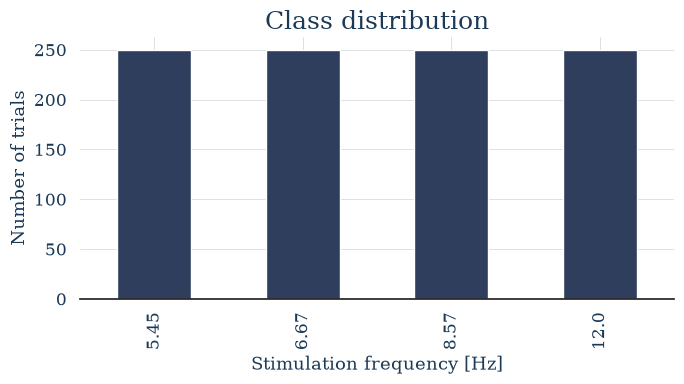

In [14]:
label_counts = pd.Series(labels_float).value_counts().sort_index()
print(label_counts)

ax = label_counts.plot(kind="bar", figsize=(7, 4))
ax.set_xlabel("Stimulation frequency [Hz]")
ax.set_ylabel("Number of trials")
ax.set_title("Class distribution")
plt.tight_layout()
plt.show()
def generate_single_harmonic_reference(
    freq: float,
    harmonic: int,
    n_samples: int,
    fs: int,
) -> np.ndarray:
    t = np.arange(n_samples) / fs

    return np.vstack([
        np.sin(2 * np.pi * harmonic * freq * t),
        np.cos(2 * np.pi * harmonic * freq * t),
    ])

# 6. Channel selection

## 6.1 Why posterior channels?

SSVEP responses are visually evoked and are usually strongest over posterior visual areas. Therefore, this notebook focuses on an occipito-parietal subset available in Lee2019_SSVEP:

```text
PO9, PO3, POz, PO4, PO10, O1, Oz, O2
```

The term **posterior channels** is used because the selected set contains both parieto-occipital and occipital channels.

## 6.2 Selected channels


In [15]:
print("Posterior channels:", POSTERIOR_CHANNELS)
print("Posterior channel indices:", POSTERIOR_CHANNEL_INDICES)

Posterior channels: ['PO9', 'PO3', 'POz', 'PO4', 'PO10', 'O1', 'Oz', 'O2']
Posterior channel indices: [27, 60, 43, 61, 31, 28, 29, 30]


## 6.3 Create posterior signal arrays

In [16]:
X_posterior_raw = X[:, POSTERIOR_CHANNEL_INDICES, :]

print("Raw posterior signal shape:", X_posterior_raw.shape)

Raw posterior signal shape: (1000, 8, 1000)


# 7. Preprocessing

## 7.1 Band-pass filtering rationale

A 5–45 Hz band-pass filter is used for spectral visualization and local-SNR analysis. This range removes slow drifts and high-frequency noise while preserving the stimulation frequencies and their first few harmonics.

Zero-phase filtering is used to avoid phase shifts in the filtered signal.

## 7.2 Apply preprocessing

In [17]:
X_filtered = filter_eeg_trials(
    X,
    lowcut=5.0,
    highcut=45.0,
    fs=FS,
    order=4,
    filter_type="cheby",
)

X_posterior_filtered = X_filtered[:, POSTERIOR_CHANNEL_INDICES, :]

print("Filtered posterior signal shape:", X_posterior_filtered.shape)

Filtered posterior signal shape: (1000, 8, 1000)


## 7.3 Raw vs filtered signal usage

The MOABB SSVEP paradigm already applies a 4–45 Hz band-pass filter and resamples to 250 Hz (see Section 5.1–5.2).

In this notebook:

- `X_posterior_filtered` (from Section 7.2) applies an *additional* 5–45 Hz Chebyshev filter for visualization and local-SNR baseline only.
- `X_posterior_raw` (from Section 6.3) is used for CCA/FBCCA functions to avoid double filtering — these methods apply their own filtering internally where needed.
- Filter-bank methods (FBCCA, FB-TRCA) apply sub-band decomposition as part of the algorithm and are not subject to double filtering.

This avoids accidental double filtering and makes model comparisons clearer.



# 8. Basic exploratory data analysis

## 8.1 Dataset dimensions

In [18]:
dataset_info = pd.DataFrame({
    "quantity": ["trials", "channels", "samples_per_trial", "trial_duration_sec"],
    "value": [n_trials, n_channels, n_samples, trial_duration_sec],
})
dataset_info

,quantity,value
0,trials,1000.0
1,channels,62.0
2,samples_per_trial,1000.0
3,trial_duration_sec,4.0


## 8.2 Label distribution

In [19]:
label_distribution_df = (
    pd.Series(labels_float)
    .value_counts()
    .sort_index()
    .rename_axis("frequency_hz")
    .reset_index(name="n_trials")
)
label_distribution_df

,frequency_hz,n_trials
0,5.45,250
1,6.67,250
2,8.57,250
3,12.00,250


## 8.3 Example EEG trial in time domain

A raw EEG trial is difficult to interpret directly in the time domain. SSVEP analysis is therefore usually performed in the frequency domain.

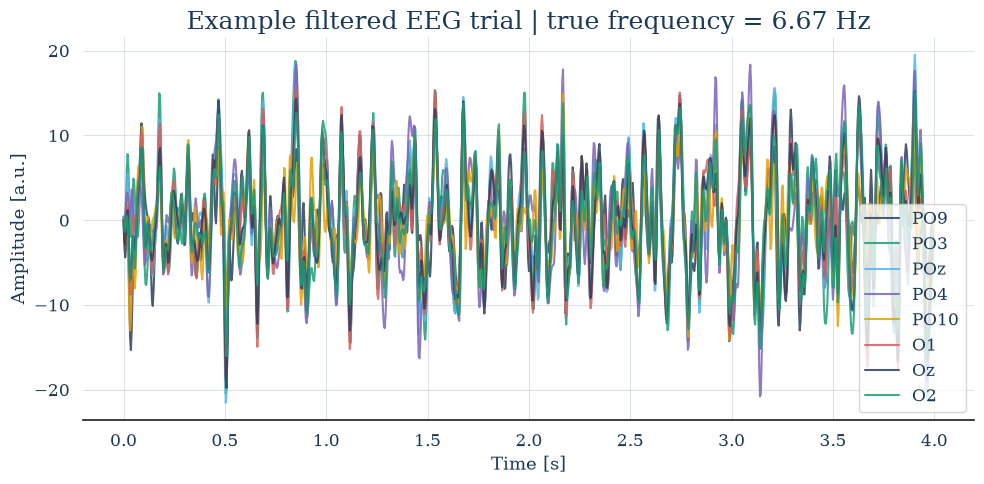

In [20]:
example_trial_idx = 0
example_trial = X_posterior_filtered[example_trial_idx]
example_label = labels_float[example_trial_idx]
time = np.arange(example_trial.shape[1]) / FS

plt.figure(figsize=(10, 5))
for ch_idx, ch_name in enumerate(POSTERIOR_CHANNELS):
    plt.plot(time, example_trial[ch_idx], label=ch_name, alpha=0.85)

plt.title(f"Example filtered EEG trial | true frequency = {example_label:.2f} Hz")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude [a.u.]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9. Spectral analysis using Welch PSD

## 9.1 Why Welch method?

Power Spectral Density (PSD) shows how signal power is distributed across frequencies. For SSVEP, the expected pattern is increased power near the stimulation frequency and its harmonics. Welch's method reduces the variance of the PSD estimate by averaging periodograms across segments.

## 9.2 Single-trial PSD

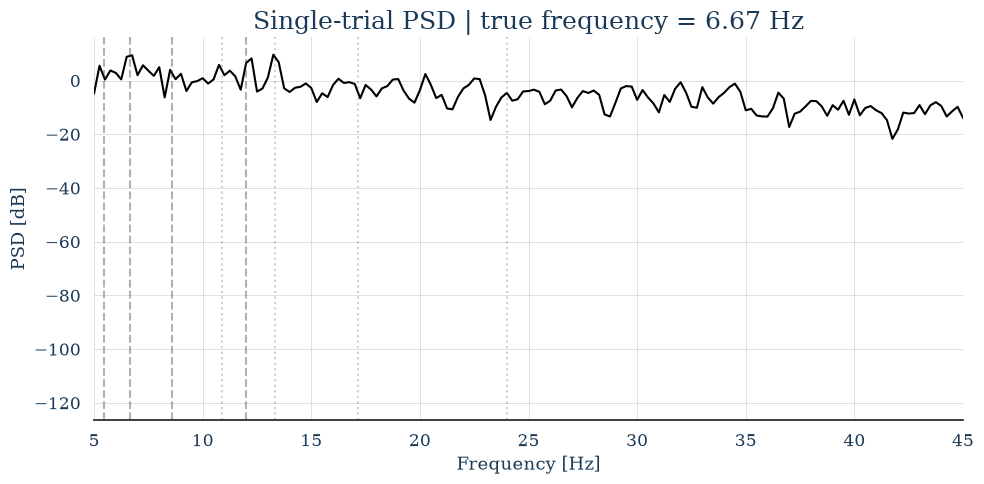

In [21]:
trial_idx = 0
trial = X_posterior_filtered[trial_idx]
current_label = labels_float[trial_idx]

freqs, psd = compute_trial_mean_psd(
    trial=trial,
    fs=FS,
    nperseg=trial.shape[1],
)
psd_db = 10 * np.log10(psd + 1e-12)

plt.figure(figsize=(10, 5))
plt.plot(freqs, psd_db, color="black", linewidth=1.5)

for f in TARGET_FREQS_ALL:
    plt.axvline(f, linestyle="--", alpha=0.4)
    if 2 * f <= 45:
        plt.axvline(2 * f, linestyle=":", alpha=0.25)

plt.xlim(5, 45)
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD [dB]")
plt.title(f"Single-trial PSD | true frequency = {current_label:.2f} Hz")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9.3 Class-wise median PSD

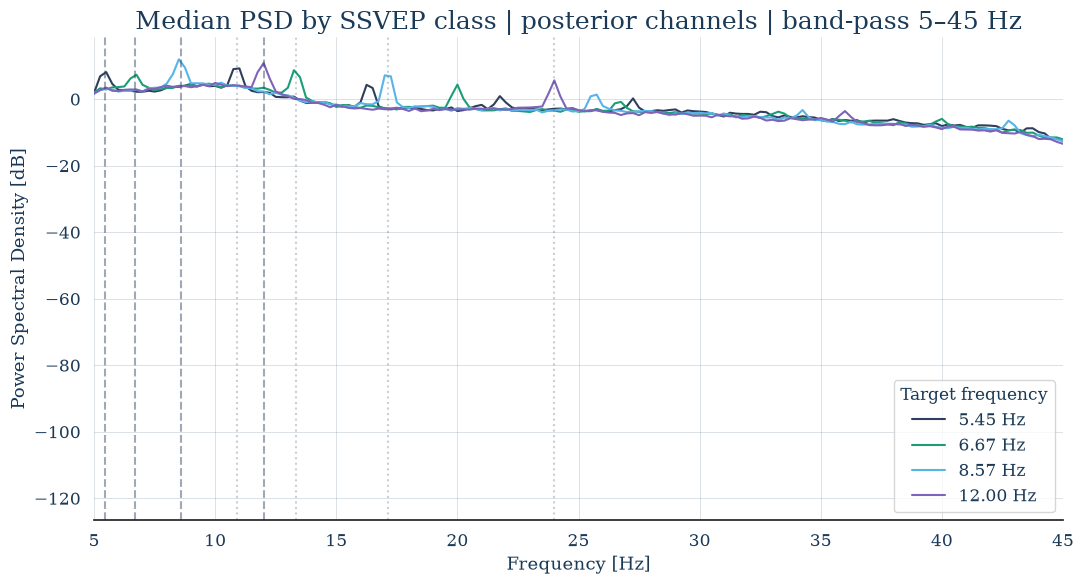

In [22]:
unique_labels = np.sort(np.unique(labels_float))

plt.figure(figsize=(11, 6))

for lab in unique_labels:
    X_lab = X_posterior_filtered[labels_float == lab]
    psds_db = []

    for trial in X_lab:
        freqs, trial_psd = compute_trial_mean_psd(
            trial=trial,
            fs=FS,
            nperseg=trial.shape[1],
        )
        psds_db.append(10 * np.log10(trial_psd + 1e-12))

    class_psd_db = np.median(psds_db, axis=0)
    plt.plot(freqs, class_psd_db, linewidth=1.5, label=f"{lab:.2f} Hz")

for f in TARGET_FREQS_ALL:
    plt.axvline(x=f, linestyle="--", alpha=0.45)
    if 2 * f <= 45:
        plt.axvline(x=2 * f, linestyle=":", alpha=0.25)

plt.title("Median PSD by SSVEP class | posterior channels | band-pass 5–45 Hz")
plt.xlim(5, 45)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power Spectral Density [dB]")
plt.legend(title="Target frequency")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9.4 PSD interpretation

The class-wise PSD plot should be interpreted qualitatively. Local peaks near the target frequencies or harmonics indicate that SSVEP-related components are present. However, strong overlap between class-wise spectra means that PSD visualization alone is not sufficient for reliable classification. This motivates local SNR, CCA and FBCCA analysis.

# 10. Local SNR analysis

## 10.1 Definition of local SNR

Local SNR compares the spectral power at a target frequency with the neighboring spectral background. In this notebook, local SNR is used both as an exploratory feature and as a simple baseline classifier.

## 10.2 SNR function

The SNR function was defined in section 4.2. It expects **linear PSD values**, not dB-transformed values.

## 10.3 SNR per trial and target frequency

In [23]:
def build_snr_dataframe(
    trials: np.ndarray,
    true_labels: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata: pd.DataFrame | None = None,
    noise_width: int = 2,
    skip_width: int = 1,
) -> pd.DataFrame:
    """Builds a trial-level SNR table for all target frequencies."""
    rows = []

    for trial_idx, trial in enumerate(trials):
        freqs, trial_psd = compute_trial_mean_psd(
            trial=trial,
            fs=fs,
            nperseg=trial.shape[1],
        )

        result = {
            "trial": trial_idx,
            "true_label": float(true_labels[trial_idx]),
        }
        result = add_metadata_to_result(result, metadata, trial_idx)

        for target_freq in target_freqs:
            snr, snr_db = compute_snr_at_freq(
                freqs=freqs,
                psd=trial_psd,
                target_freq=float(target_freq),
                noise_width=noise_width,
                skip_width=skip_width,
            )
            result[f"SNR_{target_freq:.2f}"] = snr
            result[f"SNRdB_{target_freq:.2f}"] = snr_db

        rows.append(result)

    snr_df = pd.DataFrame(rows)
    snr_columns = [f"SNR_{freq:.2f}" for freq in target_freqs]
    best_col = snr_df[snr_columns].idxmax(axis=1)

    snr_df["predicted_label"] = best_col.str.replace("SNR_", "", regex=False).astype(float)
    snr_df["correct"] = np.isclose(
        snr_df["true_label"].astype(float),
        snr_df["predicted_label"].astype(float),
        atol=0.01,
    )

    return snr_df


snr_df_4 = build_snr_dataframe(
    trials=X_posterior_filtered,
    true_labels=labels_float,
    target_freqs=TARGET_FREQS_ALL,
    fs=FS,
    metadata=metadata,
)

snr_df_4.head()

,trial,true_label,subject,session,run,SNR_5.45,SNRdB_5.45,SNR_6.67,SNRdB_6.67,SNR_8.57,SNRdB_8.57,SNR_12.00,SNRdB_12.00,predicted_label,correct
0,0,6.67,1,1,1train,1.218713,0.859015,3.842746,5.846417,1.472099,1.679369,3.884680,5.893553,12.00,False
1,1,5.45,1,1,1train,3.778093,5.772727,0.038680,-14.125120,1.612716,2.075579,0.670480,-1.736141,5.45,True
2,2,5.45,1,1,1train,1.265345,1.022091,0.355063,-4.496940,0.897168,-0.471264,0.572276,-2.423947,5.45,True
3,3,8.57,1,1,1train,1.238981,0.930647,1.211833,0.834426,2.229877,3.482809,0.465082,-3.324705,8.57,True
4,4,8.57,1,1,1train,0.681406,-1.665938,0.126229,-8.988396,0.640874,-1.932275,5.644749,7.516446,12.00,False


## 10.4 SNR-based classifier

The SNR classifier predicts the class with the highest local SNR among candidate frequencies.

## 10.5 SNR results

In [24]:
print_metrics(snr_df_4, "SNR baseline 4-class")
print("Per-class accuracy:")
print(per_class_accuracy(snr_df_4))

SNR baseline 4-class accuracy: 61.90%
SNR baseline 4-class balanced accuracy: 61.90%

              precision    recall  f1-score   support

       12.00      0.685     0.712     0.698       250
        5.45      0.563     0.628     0.594       250
        6.67      0.620     0.508     0.558       250
        8.57      0.613     0.628     0.621       250

    accuracy                          0.619      1000
   macro avg      0.620     0.619     0.618      1000
weighted avg      0.620     0.619     0.618      1000

Per-class accuracy:
true_label
5.45     0.628
6.67     0.508
8.57     0.628
12.00    0.712
Name: correct, dtype: float64


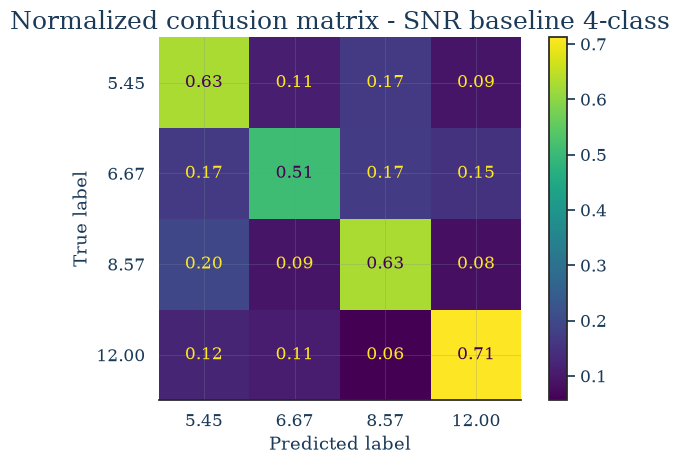

In [27]:
plot_confusion(
    snr_df_4,
    labels_order=TARGET_FREQS_ALL,
    title="Normalized confusion matrix - SNR baseline 4-class",
)

## 10.6 SNR interpretation

The SNR baseline is useful because it confirms whether local frequency-specific information exists in the signal. However, it does not fully exploit the multichannel structure of EEG and does not model the relationship between EEG channels and harmonic reference signals. Therefore, CCA is evaluated next.

# 11. CCA classification

## 11.1 Why CCA?

Canonical Correlation Analysis (CCA) is a standard method for SSVEP frequency recognition. It compares multichannel EEG data with synthetic reference signals generated at candidate stimulation frequencies.

## 11.2 Reference signals

For each candidate frequency, reference signals are generated using sine and cosine waves at the fundamental frequency and its harmonics.

## 11.3 Why sine and cosine?

The SSVEP response phase is not known in advance. Using both sine and cosine allows CCA to represent phase-shifted oscillatory responses as a linear combination of the two components.

## 11.4 CCA prediction function

In [25]:
def cca_predict(
    trials: np.ndarray,
    true_labels: np.ndarray,
    target_freqs: list[float],
    fs: int,
    filter_band: tuple[float, float] | None = None,
    n_harmonics: int = 3,
    filter_order: int = 4,
    trim_start_sec: float = 0.0,
    metadata: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """Predicts SSVEP classes using standard CCA."""
    start_sample = int(trim_start_sec * fs)
    trials_used = trials[:, :, start_sample:] if start_sample > 0 else trials
    n_samples = trials_used.shape[2]

    references = {
        float(freq): generate_reference_signals(
            freq=float(freq),
            n_samples=n_samples,
            fs=fs,
            n_harmonics=n_harmonics,
        )
        for freq in target_freqs
    }

    results = []

    for trial_idx, trial in enumerate(trials_used):
        if filter_band is not None:
            lowcut, highcut = filter_band
            trial_for_cca = filter_trial(
                trial=trial,
                lowcut=lowcut,
                highcut=highcut,
                fs=fs,
                order=filter_order,
                filter_type="butter",
            )
        else:
            trial_for_cca = trial

        class_scores = {}

        for target_freq in target_freqs:
            target_freq = float(target_freq)
            rho = get_cca_correlation(
                data=trial_for_cca,
                ref=references[target_freq],
            )
            class_scores[target_freq] = rho

        predicted_freq = max(class_scores, key=class_scores.get)

        result = {
            "trial": trial_idx,
            "true_label": float(true_labels[trial_idx]),
            "predicted_label": float(predicted_freq),
            "cca_score": float(class_scores[predicted_freq]),
        }
        result = add_metadata_to_result(result, metadata, trial_idx)

        for freq, score in class_scores.items():
            result[f"CCA_{freq:.2f}"] = float(score)

        results.append(result)

    cca_df = pd.DataFrame(results)
    cca_df["correct"] = np.isclose(
        cca_df["true_label"].astype(float),
        cca_df["predicted_label"].astype(float),
        atol=0.01,
    )

    return cca_df

## 11.5 CCA 4-class results


In [26]:
cca_df_4 = cca_predict(
    trials=X_posterior_raw,
    true_labels=labels_float,
    target_freqs=TARGET_FREQS_ALL,
    fs=FS,
    filter_band=(5, 45),
    n_harmonics=3,
    trim_start_sec=0.0,
    metadata=metadata,
)

print_metrics(cca_df_4, "CCA 4-class")
print("Per-class accuracy:")
print(per_class_accuracy(cca_df_4))

CCA 4-class accuracy: 95.10%
CCA 4-class balanced accuracy: 95.10%

              precision    recall  f1-score   support

       12.00      0.991     0.904     0.946       250
        5.45      0.925     0.980     0.951       250
        6.67      0.992     0.944     0.967       250
        8.57      0.907     0.976     0.940       250

    accuracy                          0.951      1000
   macro avg      0.954     0.951     0.951      1000
weighted avg      0.954     0.951     0.951      1000

Per-class accuracy:
true_label
5.45     0.980
6.67     0.944
8.57     0.976
12.00    0.904
Name: correct, dtype: float64


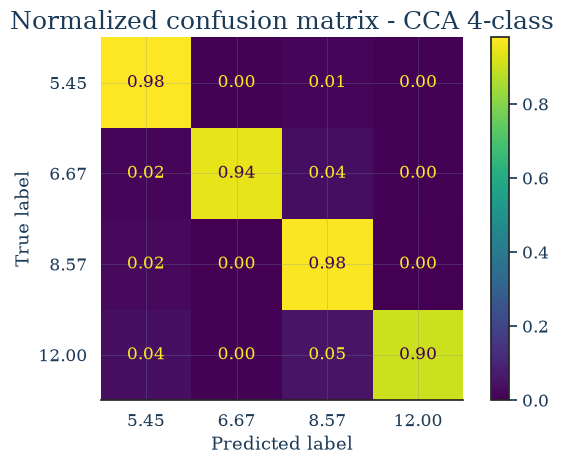

In [27]:
plot_confusion(
    cca_df_4,
    labels_order=TARGET_FREQS_ALL,
    title="Normalized confusion matrix - CCA 4-class",
)

## 11.7 CCA interpretation

CCA is expected to improve over the local-SNR baseline because it uses multichannel EEG and compares it with harmonic sine/cosine references. Class-wise accuracy and the confusion matrix should be used to identify weak frequencies.

# 12. FBCCA classification

## 12.1 Why FBCCA?

Filter Bank CCA (FBCCA) extends standard CCA by applying CCA across multiple frequency subbands and combining the resulting correlations using weights. This is useful in SSVEP analysis because relevant information can appear not only at the fundamental stimulation frequency but also at harmonic components.

## 12.2 Filter bank design

The default filter bank used here is:

```text
(5, 45), (10, 45), (15, 45)
```

This is intentionally less aggressive than higher low-cut banks because the Lee2019_SSVEP target frequencies include low-frequency stimulation at 5.45 Hz and 6.67 Hz.

## 12.3 FBCCA weights

The default weights follow the common decreasing-weight rule:

```text
w_m = m^(-1.25) + 0.25
```

The first subband receives the highest weight, while higher subbands receive lower weights.

## 12.4 FBCCA prediction function

In [28]:
def fbcca_predict(
    trials: np.ndarray,
    true_labels: np.ndarray,
    target_freqs: list[float],
    fs: int,
    filter_bands: list[tuple[float, float]] | None = None,
    n_harmonics: int = 3,
    filter_order: int = 4,
    trim_start_sec: float = 0.0,
    metadata: pd.DataFrame | None = None,
    weights: np.ndarray | None = None,
) -> pd.DataFrame:
    """Predicts SSVEP classes using simplified FBCCA."""
    if filter_bands is None:
        filter_bands = [(5, 45), (10, 45), (15, 45)]

    start_sample = int(trim_start_sec * fs)
    trials_used = trials[:, :, start_sample:] if start_sample > 0 else trials
    n_samples = trials_used.shape[2]

    references = {
        float(freq): generate_reference_signals(
            freq=float(freq),
            n_samples=n_samples,
            fs=fs,
            n_harmonics=n_harmonics,
        )
        for freq in target_freqs
    }

    if weights is None:
        weights = np.array([
            (band_idx + 1) ** (-1.25) + 0.25
            for band_idx in range(len(filter_bands))
        ])
    else:
        weights = np.asarray(weights)

    results = []

    for trial_idx, trial in enumerate(trials_used):
        filtered_subbands = []

        # Filtering does not depend on target frequency, so it is done once per subband.
        for lowcut, highcut in filter_bands:
            filtered_trial = filter_trial(
                trial=trial,
                lowcut=lowcut,
                highcut=highcut,
                fs=fs,
                order=filter_order,
                filter_type="butter",
            )
            filtered_subbands.append(filtered_trial)

        class_scores = {}

        for target_freq in target_freqs:
            target_freq = float(target_freq)
            subband_scores = []

            for filtered_trial in filtered_subbands:
                rho = get_cca_correlation(
                    data=filtered_trial,
                    ref=references[target_freq],
                )
                subband_scores.append(rho ** 2)

            final_score = np.dot(np.array(subband_scores), weights[:len(subband_scores)])
            class_scores[target_freq] = final_score

        predicted_freq = max(class_scores, key=class_scores.get)

        result = {
            "trial": trial_idx,
            "true_label": float(true_labels[trial_idx]),
            "predicted_label": float(predicted_freq),
            "fbcca_score": float(class_scores[predicted_freq]),
        }
        result = add_metadata_to_result(result, metadata, trial_idx)

        for freq, score in class_scores.items():
            result[f"FBCCA_{freq:.2f}"] = float(score)

        results.append(result)

    fbcca_df = pd.DataFrame(results)
    fbcca_df["correct"] = np.isclose(
        fbcca_df["true_label"].astype(float),
        fbcca_df["predicted_label"].astype(float),
        atol=0.01,
    )

    return fbcca_df

## 12.5 FBCCA 4-class results


In [29]:
DEFAULT_FBCCA_BANDS = [(5, 45), (10, 45), (15, 45)]

fbcca_df_4 = fbcca_predict(
    trials=X_posterior_raw,
    true_labels=labels_float,
    target_freqs=TARGET_FREQS_ALL,
    fs=FS,
    filter_bands=DEFAULT_FBCCA_BANDS,
    n_harmonics=3,
    trim_start_sec=0.0,
    metadata=metadata,
)

print_metrics(fbcca_df_4, "FBCCA 4-class")
print("Per-class accuracy:")
print(per_class_accuracy(fbcca_df_4))

FBCCA 4-class accuracy: 97.60%
FBCCA 4-class balanced accuracy: 97.60%

              precision    recall  f1-score   support

       12.00      0.988     0.956     0.972       250
        5.45      0.954     0.992     0.973       250
        6.67      0.992     0.976     0.984       250
        8.57      0.972     0.980     0.976       250

    accuracy                          0.976      1000
   macro avg      0.976     0.976     0.976      1000
weighted avg      0.976     0.976     0.976      1000

Per-class accuracy:
true_label
5.45     0.992
6.67     0.976
8.57     0.980
12.00    0.956
Name: correct, dtype: float64


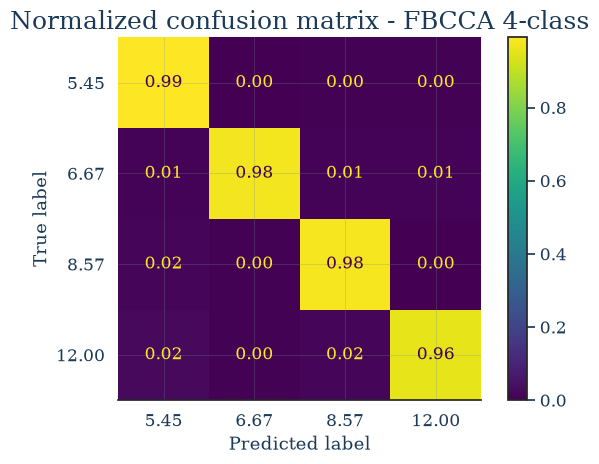

In [30]:
plot_confusion(
    fbcca_df_4,
    labels_order=TARGET_FREQS_ALL,
    title="Normalized confusion matrix - FBCCA 4-class",
)

## Final baseline result

For this project, **4-class FBCCA is the endpoint of the primary/simple notebook**.

Saved result from the source run:

- **Accuracy:** 97.60%
- **Balanced accuracy:** 97.60%
- **Classes:** 4
- **Chance level:** 25%
- **Trials:** 1000
- **Default filter bank:** `(5–45), (10–45), (15–45) Hz`
- **CCA harmonics:** 3

This is already a strong calibration-free classifier for the four-command SSVEP problem.
Further methods are treated as optional experimental extensions rather than requirements
for the basic EDA/classification pipeline.


## 12.7 FBCCA interpretation

FBCCA should be compared with standard CCA using the same channels and the same candidate frequencies. If FBCCA improves only slightly, this suggests that filter-bank information is helpful but not sufficient to solve weak class separability.

# References

1. MOABB Lee2019_SSVEP documentation:  
   https://moabb.neurotechx.com/docs/generated/moabb.datasets.Lee2019_SSVEP.html

2. Lee et al. 2019, EEG dataset and OpenBMI toolbox for three BCI paradigms:  
   https://doi.org/10.1093/gigascience/giz002

3. Lin et al. — canonical correlation analysis for SSVEP-based BCIs:  
   https://pubmed.ncbi.nlm.nih.gov/17549911/

4. Chen et al. — filter bank canonical correlation analysis (FBCCA):  
   https://pubmed.ncbi.nlm.nih.gov/26035476/
